<a href="https://colab.research.google.com/github/EvM82/Classical-Machine-Learning-for-Classifi--cation/blob/main/SVM_LDA_kPCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## libsvm load/import

In [ ]:
!pip install -q libsvm-official

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from libsvm.svmutil import *

## Imports

In [ ]:
import os
import pandas as pd
import numpy as np
from time import time
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestCentroid
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import NearestCentroid
from PIL import Image
from sklearn.decomposition import PCA
from scipy.linalg import eigh
from sklearn.decomposition import KernelPCA
import matplotlib.pyplot as plt


# Datasets

## PC Parts dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Load the dataset PC Parts (from drive), read the seperate files of each class and save into 1 Dataframe.

In [ ]:
root_dir = "/content/drive/MyDrive/pc_parts"
data = []

for label in os.listdir(root_dir):
    label_path = os.path.join(root_dir, label)

    if not os.path.isdir(label_path):
        continue

    for filename in os.listdir(label_path):
        filepath = os.path.join(label_path, filename)

        if filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif")):
            data.append([filepath, label])

df = pd.DataFrame(data, columns=["filepath", "label"])

print(df.head())
print("Σύνολο εικόνων:", len(df))


                                          filepath    label
0  /content/drive/MyDrive/pc_parts/headset/120.jpg  headset
1  /content/drive/MyDrive/pc_parts/headset/144.jpg  headset
2  /content/drive/MyDrive/pc_parts/headset/149.jpg  headset
3  /content/drive/MyDrive/pc_parts/headset/143.jpg  headset
4  /content/drive/MyDrive/pc_parts/headset/129.jpg  headset
Σύνολο εικόνων: 894


Processing the data to create train-test and bring them to the suitable form libsvm requires.

In [ ]:
#Function to convert images (the ones of df to 32x32)
def load_and_resize(path, size=(32, 32)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.array(img)

X = np.stack(df["filepath"].apply(lambda p: load_and_resize(p, (32, 32))))
y = df["label"].values

print("Raw X shape:", X.shape)
print("Raw y shape:", y.shape)

# Transform labels in integer form
le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Unique labels:", le.classes_)
print("y_enc shape:", y_enc.shape)


# Split the dataset in train and test
X_train, X_test, y_train, y_test = train_test_split(X, y_enc,test_size=0.2,stratify=y_enc,random_state=42)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

# Flatten: (N,32,32,3) -> (N, 3072)
x_train = X_train.reshape(len(X_train), -1).astype("float32")
x_test  = X_test.reshape(len(X_test),  -1).astype("float32")

print("After flatten:")
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

# Normalization of data
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled  = scaler.transform(x_test)

#LIBSVM format:
# Ensure that labels are 1D
y_train = y_train.ravel()
y_test  = y_test.ravel()

x_train_lib = x_train_scaled.tolist()
y_train_lib = y_train.tolist()

#Transform in lists- LIBSVM requires lists not numpy array
# for exercise 2 this part bellow is not executed
'''x_test_lib = x_test_scaled.tolist()
y_test_lib = y_test.tolist()'''

Raw X shape: (894, 32, 32, 3)
Raw y shape: (894,)
Unique labels: ['cpu' 'gpu' 'headset' 'keyboard' 'microphone']
y_enc shape: (894,)
X_train: (715, 32, 32, 3) y_train: (715,)
X_test : (179, 32, 32, 3) y_test : (179,)
After flatten:
x_train: (715, 3072)
x_test : (179, 3072)


'x_test_lib = x_test_scaled.tolist()\ny_test_lib = y_test.tolist()'

## load cifar dataset

In [ ]:
from tensorflow.keras.datasets import cifar10

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test :", x_test.shape,  "y_test :", y_test.shape)

x_train: (50000, 32, 32, 3) y_train: (50000, 1)
x_test : (10000, 32, 32, 3) y_test : (10000, 1)


## Data processing cifar 10



In [ ]:
# Flatten: 32x32x3 -> 3072 features
x_train = x_train.reshape(len(x_train), -1).astype('float32')
x_test  = x_test.reshape(len(x_test),  -1).astype('float32')

# Normalization of data
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled  = scaler.transform(x_test)


#LIBSVM format:
# Ensure that labels are 1D
y_train = y_train.ravel()
y_test  = y_test.ravel()

print("X_train:", x_train_scaled.shape, "y_train:", y_train.shape)
print("X_test :", x_test_scaled.shape,  "y_test :", y_test.shape)

X_train: (50000, 3072) y_train: (50000,)
X_test : (10000, 3072) y_test : (10000,)


The code bellow for this section, is for the 1st exercise only.

PCA--for 1st exercise

In [ ]:
# Applying PCA function on training and testing
# This part is executed only when the algorithms are run for PCA in CIFAR
pca = PCA(n_components=0.90)

x_train_scaled = pca.fit_transform(x_train_scaled)
x_test_scaled = pca.transform(x_test_scaled)

explained_variance = pca.explained_variance_ratio_

Use subsets for train to use in grid search -- for 1st exercise

In [ ]:
n_train = 2000
x_train_sub = x_train_scaled[:n_train]
y_train_sub = y_train[:n_train]

print(f"\n subset: {n_train} train for grid search")

#Transform in lists- LIBSVM requires lists not numpy array
x_train_lib = x_train_sub.tolist()
y_train_lib = y_train_sub.tolist()


 subset: 2000 train for grid search


The PCA kept 90% of the information and from the original 3072 dimensions, keeping only 99 of them.

In [ ]:
print(x_train.shape, y_train.shape)


(50000, 3072) (50000,)


In [ ]:
print(x_train_sub.shape, y_train_sub.shape)
print(np.unique(y_train_sub))

(2000, 99) (2000,)
[0 1 2 3 4 5 6 7 8 9]


# 1st part - SVM

## SVM grid for rbf

In [ ]:
#loose grid
#The values to be searched are adjusted depending on the experiment (PCA, dataset).
C_values = [0.1, 1, 10, 100]
gamma_values = [1e-4, 1e-3, 1e-2, 1e-1]

best_acc = -1
best_C, best_g = None, None
count=0


for C in C_values:
    for g in gamma_values:
        count += 1
        print(f"Running combination {count}:  C={C}, gamma={g}")
        param = f'-s 0 -t 2 -c {C} -g {g} -v 5 -q'
        cv_acc = svm_train(y_train_lib, x_train_lib, param)
        if cv_acc > best_acc:
            best_acc = cv_acc
            best_C, best_g = C, g

print("Best C, g:", best_C, best_g, "CV acc:", best_acc)

Running combination 1:  C=0.1, gamma=0.0001
Cross Validation Accuracy = 27.4126%
Running combination 2:  C=0.1, gamma=0.001
Cross Validation Accuracy = 29.6503%
Running combination 3:  C=0.1, gamma=0.01
Cross Validation Accuracy = 27.4126%
Running combination 4:  C=0.1, gamma=0.1
Cross Validation Accuracy = 27.4126%
Running combination 5:  C=1, gamma=0.0001
Cross Validation Accuracy = 38.8811%
Running combination 6:  C=1, gamma=0.001
Cross Validation Accuracy = 47.1329%
Running combination 7:  C=1, gamma=0.01
Cross Validation Accuracy = 29.0909%
Running combination 8:  C=1, gamma=0.1
Cross Validation Accuracy = 28.5315%
Running combination 9:  C=10, gamma=0.0001
Cross Validation Accuracy = 44.8951%
Running combination 10:  C=10, gamma=0.001
Cross Validation Accuracy = 47.972%
Running combination 11:  C=10, gamma=0.01
Cross Validation Accuracy = 29.2308%
Running combination 12:  C=10, gamma=0.1
Cross Validation Accuracy = 28.6713%
Running combination 13:  C=100, gamma=0.0001
Cross Valid

Fine grid based on the values of C, γ.

In [ ]:
# fine grid
#The values to be searched are adjusted depending on the experiment (PCA, dataset).
gamma_values = [ 0.0005, 0.001, 0.002]

best_acc = -1
best_C, best_g = None, None
count=0

for C in C_values:
    for g in gamma_values:
        count += 1
        print(f"Running combination {count}:  C={C}, gamma={g}")
        param = f'-s 0 -t 2 -c {C} -g {g} -v 5 -q'
        cv_acc = svm_train(y_train_lib, x_train_lib, param)
        if cv_acc > best_acc:
            best_acc = cv_acc
            best_C, best_g = C, g

print("Best C, g:", best_C, best_g, "CV acc:", best_acc)

Running combination 1:  C=50, gamma=0.0005
Cross Validation Accuracy = 48.5315%
Running combination 2:  C=50, gamma=0.001
Cross Validation Accuracy = 47.5524%
Running combination 3:  C=50, gamma=0.002
Cross Validation Accuracy = 49.0909%
Running combination 4:  C=80, gamma=0.0005
Cross Validation Accuracy = 47.1329%
Running combination 5:  C=80, gamma=0.001
Cross Validation Accuracy = 49.5105%
Running combination 6:  C=80, gamma=0.002
Cross Validation Accuracy = 48.2517%
Running combination 7:  C=100, gamma=0.0005
Cross Validation Accuracy = 48.2517%
Running combination 8:  C=100, gamma=0.001
Cross Validation Accuracy = 49.7902%
Running combination 9:  C=100, gamma=0.002
Cross Validation Accuracy = 48.1119%
Running combination 10:  C=150, gamma=0.0005
Cross Validation Accuracy = 48.1119%
Running combination 11:  C=150, gamma=0.001
Cross Validation Accuracy = 48.3916%
Running combination 12:  C=150, gamma=0.002
Cross Validation Accuracy = 47.4126%
Best C, g: 100 0.001 CV acc: 49.7902097

## Grid for Polynomial

In [ ]:
# loose grid for polynomial kernel (degree 2)
#The values to be searched are adjusted depending on the experiment (PCA, dataset).
C_values     = [0.1, 1, 10, 100]
gamma_values = [1e-4, 1e-3, 1e-2, 1e-1]
r_values     = [0, 1]

best_acc = -1
best_C, best_g, best_r = None, None, None
count = 0
total = len(C_values) * len(gamma_values) * len(r_values)

for C in C_values:
    for g in gamma_values:
        for r in r_values:
            count += 1
            print(f"Running combination {count}/{total}: C={C}, gamma={g}, r={r}")

            # -t 1: polynomial, -d 2: degree 2
            param = f'-s 0 -t 1 -d 2 -c {C} -g {g} -r {r} -v 5 -q'

            cv_acc = svm_train(y_train_lib, x_train_lib, param)

            if cv_acc > best_acc:
                best_acc = cv_acc
                best_C, best_g, best_r = C, g, r

print("\nBest C, g, r:", best_C, best_g, best_r, "CV acc:", best_acc)


Running combination 1/32: C=0.1, gamma=0.0001, r=0
Cross Validation Accuracy = 27.4126%
Running combination 2/32: C=0.1, gamma=0.0001, r=1
Cross Validation Accuracy = 27.6923%
Running combination 3/32: C=0.1, gamma=0.001, r=0
Cross Validation Accuracy = 41.6783%
Running combination 4/32: C=0.1, gamma=0.001, r=1
Cross Validation Accuracy = 41.5385%
Running combination 5/32: C=0.1, gamma=0.01, r=0
Cross Validation Accuracy = 44.1958%
Running combination 6/32: C=0.1, gamma=0.01, r=1
Cross Validation Accuracy = 44.3357%
Running combination 7/32: C=0.1, gamma=0.1, r=0
Cross Validation Accuracy = 43.4965%
Running combination 8/32: C=0.1, gamma=0.1, r=1
Cross Validation Accuracy = 42.5175%
Running combination 9/32: C=1, gamma=0.0001, r=0
Cross Validation Accuracy = 27.972%
Running combination 10/32: C=1, gamma=0.0001, r=1
Cross Validation Accuracy = 39.5804%
Running combination 11/32: C=1, gamma=0.001, r=0
Cross Validation Accuracy = 43.9161%
Running combination 12/32: C=1, gamma=0.001, r=1
C

Fine grid

In [ ]:
#fine grid
#The values to be searched are adjusted depending on the experiment (PCA, dataset).
C_values =  [5, 8, 10, 15]
gamma_values = [0.005, 0.008, 0.01, 0.015]
r_values = [1,1.5]


best_acc = -1
best_C, best_g, best_r = None, None, None
count = 0
total = len(C_values) * len(gamma_values) * len(r_values)

for C in C_values:
    for g in gamma_values:
        for r in r_values:
            count += 1
            print(f"Running combination {count}/{total}: C={C}, gamma={g}, r={r}")

            # -t 1: polynomial, -d 2: degree 2
            param = f'-s 0 -t 1 -d 2 -c {C} -g {g} -r {r} -v 5 -q'

            cv_acc = svm_train(y_train_lib, x_train_lib, param)

            if cv_acc > best_acc:
                best_acc = cv_acc
                best_C, best_g, best_r = C, g, r

print("\nBest C, g, r:", best_C, best_g, best_r, "CV acc:", best_acc)


Running combination 1/32: C=5, gamma=0.005, r=1
Cross Validation Accuracy = 44.1958%
Running combination 2/32: C=5, gamma=0.005, r=1.5
Cross Validation Accuracy = 44.7552%
Running combination 3/32: C=5, gamma=0.008, r=1
Cross Validation Accuracy = 42.6573%
Running combination 4/32: C=5, gamma=0.008, r=1.5
Cross Validation Accuracy = 44.8951%
Running combination 5/32: C=5, gamma=0.01, r=1
Cross Validation Accuracy = 44.3357%
Running combination 6/32: C=5, gamma=0.01, r=1.5
Cross Validation Accuracy = 44.4755%
Running combination 7/32: C=5, gamma=0.015, r=1
Cross Validation Accuracy = 44.0559%
Running combination 8/32: C=5, gamma=0.015, r=1.5
Cross Validation Accuracy = 44.7552%
Running combination 9/32: C=8, gamma=0.005, r=1
Cross Validation Accuracy = 46.5734%
Running combination 10/32: C=8, gamma=0.005, r=1.5
Cross Validation Accuracy = 43.9161%
Running combination 11/32: C=8, gamma=0.008, r=1
Cross Validation Accuracy = 44.0559%
Running combination 12/32: C=8, gamma=0.008, r=1.5
Cros

## Grid for Linear

In [ ]:
#loose grid
#The values to be searched are adjusted depending on the experiment (PCA, dataset).
C_values = [0.01, 0.1, 1, 10, 100]

best_acc = -1
best_C = None
count = 0

for C in C_values:
    count += 1
    print(f"Running combination {count}: C={C}")

    param = f'-s 0 -t 0 -c {C} -v 5 -q'
    cv_acc = svm_train(y_train_lib, x_train_lib, param)

    if cv_acc > best_acc:
        best_acc = cv_acc
        best_C = C

print("Best C:", best_C, "CV acc:", best_acc)


Running combination 1: C=0.01
Cross Validation Accuracy = 35.5245%
Running combination 2: C=0.1
Cross Validation Accuracy = 33.986%
Running combination 3: C=1
Cross Validation Accuracy = 32.4476%
Running combination 4: C=10
Cross Validation Accuracy = 35.1049%
Running combination 5: C=100
Cross Validation Accuracy = 32.028%
Best C: 0.01 CV acc: 35.52447552447553


Fine grid

In [ ]:
#fine grid
#The values to be searched are adjusted depending on the experiment (PCA, dataset).
C_values= [0.002, 0.005, 0.008, 0.01,0.02]

best_acc = -1
best_C = None
count = 0

for C in C_values:
    count += 1
    print(f"Running combination {count}: C={C}")

    param = f'-s 0 -t 0 -c {C} -v 5 -q'
    cv_acc = svm_train(y_train_lib, x_train_lib, param)

    if cv_acc > best_acc:
        best_acc = cv_acc
        best_C = C

print("Best C:", best_C, "CV acc:", best_acc)


Running combination 1: C=0.002
Cross Validation Accuracy = 42.0979%
Running combination 2: C=0.005
Cross Validation Accuracy = 38.4615%
Running combination 3: C=0.008
Cross Validation Accuracy = 38.3217%
Running combination 4: C=0.01
Cross Validation Accuracy = 37.4825%
Running combination 5: C=0.02
Cross Validation Accuracy = 34.8252%
Best C: 0.002 CV acc: 42.09790209790209


## preprocess the train - test for the CIFAR NOT for the PC Parts



The PC Parts dataset is already small in size, so all available samples are used in every experiment. Therefore, this cell is not needed when working with the PC Parts dataset.

Use bigger train subsets for the final training.
Keep 10.000 for the training and 5.000 for the test.

In [ ]:
n_train = 10000
n_test  = 5000

x_train_f = x_train_scaled[:n_train]
y_train_f = y_train[:n_train]
x_test_f  = x_test_scaled[:n_test]
y_test_f  = y_test[:n_test]

print(f"\n subset: {n_train} train, {n_test} test samples")

#Transform in lists- LIBSVM requires lists not numpy array
x_train_lib = x_train_f.tolist()
x_test_lib  = x_test_f.tolist()
y_train_lib = y_train_f.tolist()
y_test_lib  = y_test_f.tolist()



 subset: 10000 train, 5000 test samples


## Train for the best parameters

The cell bellow is to see the shape of CIFAR only.
In the case of CIFAR, the variable x_train_f/x_test_f is introduced because only a subset of the dataset is utilized. This is necessary due to computational constraints that prevent processing the entire CIFAR dataset in every experiment.
PC Parts doesn't need subsets, so x_train/x_test is used.

In [ ]:
print(x_train_f.shape, y_train_f.shape)
print(x_test_f.shape, y_test_f.shape)
print(np.unique(y_train_f))

(10000, 99) (10000,)
(5000, 99) (5000,)
[0 1 2 3 4 5 6 7 8 9]


The cell bellow is for the shape of the PC Parts dataset.

In [ ]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(np.unique(y_train))

(50000, 3072) (50000,)
(10000, 3072) (10000,)
[0 1 2 3 4 5 6 7 8 9]


The cell bellow is for the final run for both CIFAR and PC Parts.

In [ ]:
#In param_final, the arguments are configured according to the kernel used in each experiment,
#and they incorporate the best hyperparameters identified.
param_final = '-s 0 -t 1 -d 2 -c 10 -g 0.005 -r 1 -m 500 -h 1 -q'
start_test = time()
model = svm_train(y_train_lib, x_train_lib, param_final)
end_test = time()
print(f"Training in {end_test - start_test:.2f} seconds.")

#PREDICT IN TRAIN
train_labels, train_acc, train_vals = svm_predict(y_train_lib, x_train_lib, model, '-q')
print("Training accuracy:", train_acc[0])

#PREDICT IN TEST
start_test = time()
p_labels, p_acc, p_vals = svm_predict(y_test_lib, x_test_lib, model, '-q')
end_test = time()
print(f"Prediction in {end_test - start_test:.2f} seconds.")
print("Final test accuracy:", p_acc[0])



Training in 4.56 seconds.
Training accuracy: 98.74125874125875
Prediction in 1.02 seconds.
Final test accuracy: 45.2513966480447


##κΝΝ κ=1

In [ ]:
# Fine tuning for weights & metric
param_grid_knn = { 'weights': ['uniform', 'distance'],'metric': ['euclidean', 'manhattan']}

knn = KNeighborsClassifier(n_neighbors=1)

grid_knn = GridSearchCV(estimator=knn,param_grid=param_grid_knn,cv=5,n_jobs=-1,verbose=1)

#for cifar
#grid_knn.fit(x_train_sub, y_train_sub)

#for pc parts
grid_knn.fit(x_train_scaled, y_train)


print("Best params (k-NN):", grid_knn.best_params_)
print("Best CV accuracy (k-NN):", grid_knn.best_score_)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
Best params (k-NN): {'metric': 'manhattan', 'weights': 'uniform'}
Best CV accuracy (k-NN): 0.44475524475524475


## For CIFAR kNN final training for best parameters

In [ ]:
n_train = 10000
n_test  = 5000

x_train_f = x_train_scaled[:n_train]
y_train_f = y_train[:n_train]
x_test_f  = x_test_scaled[:n_test]
y_test_f  = y_test[:n_test]

print(f"\n subset: {n_train} train, {n_test} test samples")


 subset: 10000 train, 5000 test samples


In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=1, metric='euclidean',weights='uniform', n_jobs=-1  )

best_knn.fit(x_train_f, y_train_f)

# Predict in train
y_train_pred_knn = best_knn.predict(x_train_f)
train_acc_knn = accuracy_score(y_train_f, y_train_pred_knn)

# Predict in test
y_test_pred_knn = best_knn.predict(x_test_f)
test_acc_knn = accuracy_score(y_test_f, y_test_pred_knn)

print(f"k-NN training accuracy: {train_acc_knn * 100:.2f}%")
print(f"k-NN test accuracy:     {test_acc_knn * 100:.2f}%")


k-NN training accuracy: 100.00%
k-NN test accuracy:     30.68%


## For PC parts kNN final training

In [ ]:
best_knn = KNeighborsClassifier(n_neighbors=1, metric='manhattan',weights='uniform', n_jobs=-1  )

best_knn.fit(x_train_scaled, y_train)

# Predict in train
y_train_pred_knn = best_knn.predict(x_train_scaled)
train_acc_knn = accuracy_score(y_train, y_train_pred_knn)

# Predict in test
y_test_pred_knn = best_knn.predict(x_test_scaled)
test_acc_knn = accuracy_score(y_test, y_test_pred_knn)

print(f"k-NN training accuracy: {train_acc_knn * 100:.2f}%")
print(f"k-NN test accuracy:     {test_acc_knn * 100:.2f}%")


k-NN training accuracy: 100.00%
k-NN test accuracy:     37.22%


## NCC

In [ ]:
param_grid_ncc = { 'metric': ['euclidean', 'manhattan'],'shrink_threshold': [None, 0.1, 0.5, 1.0, 2.0]}

ncc = NearestCentroid()

grid_ncc = GridSearchCV(estimator=ncc,param_grid=param_grid_ncc,cv=5,n_jobs=-1,verbose=1)

#for CIFAR
#grid_ncc.fit(x_train_sub, y_train_sub)

#for PC parts
grid_ncc.fit(x_train_scaled, y_train)

print("\nBest params (NCC):", grid_ncc.best_params_)
print("Best CV accuracy (NCC):", grid_ncc.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best params (NCC): {'metric': 'manhattan', 'shrink_threshold': None}
Best CV accuracy (NCC): 0.3384615384615385


## CIFAR final training for best parametres ncc



In [ ]:
n_train = 10000
n_test  = 5000

x_train_f = x_train_scaled[:n_train]
y_train_f = y_train[:n_train]
x_test_f  = x_test_scaled[:n_test]
y_test_f  = y_test[:n_test]

print(f"\n subset: {n_train} train, {n_test} test samples")


 subset: 10000 train, 5000 test samples


In [ ]:
best_ncc = NearestCentroid(
    metric='manhattan',
    shrink_threshold=0.1
)
best_ncc.fit(x_train_f, y_train_f)

# --- Train accuracy ---
y_train_pred = best_ncc.predict(x_train_f)
train_acc_ncc = accuracy_score(y_train_f, y_train_pred)

# --- Test accuracy ---
y_test_pred = best_ncc.predict(x_test_f)
test_acc_ncc = accuracy_score(y_test_f, y_test_pred)

print(f"NCC training accuracy: {train_acc_ncc * 100:.2f}%")
print(f"NCC test accuracy:     {test_acc_ncc * 100:.2f}%")

NCC training accuracy: 29.64%
NCC test accuracy:     28.62%


## PC Parts final training for best parametres ncc



In [ ]:
best_ncc = NearestCentroid( metric='manhattan',shrink_threshold=None)

best_ncc.fit(x_train_scaled, y_train)

# Predict in train
y_train_pred = best_ncc.predict(x_train_scaled)
train_acc_ncc = accuracy_score(y_train, y_train_pred)

# Predict in test
y_test_pred = best_ncc.predict(x_test_scaled)
test_acc_ncc = accuracy_score(y_test, y_test_pred)

print(f"NCC training accuracy: {train_acc_ncc * 100:.2f}%")
print(f"NCC test accuracy:     {test_acc_ncc * 100:.2f}%")


NCC training accuracy: 37.06%
NCC test accuracy:     34.64%


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/ergasia2.ipynb"


# 2nd Part -LDA & kPCA

## LDA Code creation

In [ ]:
def lda_fit_transform(X, y, n_components=None, eps=1e-4):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y)

    classes = np.unique(y)
    C = len(classes)
    if C < 2:
        raise ValueError("LDA requires at least 2 classes.")

    means = {}
    counts = {}
    for c in classes:
        Xc = X[y == c]
        means[c] = Xc.mean(axis=0)
        counts[c] = Xc.shape[0]
    mu = X.mean(axis=0)


    N, d = X.shape
    SW = np.zeros((d, d), dtype=np.float64)
    for c in classes:
        Xc = X[y == c]
        Xc_centered = Xc - means[c]
        SW += Xc_centered.T @ Xc_centered

    SB = np.zeros((d, d), dtype=np.float64)
    for c in classes:
        diff = (means[c] - mu).reshape(-1, 1)
        SB += counts[c] * (diff @ diff.T)


    print(f"SW shape: {SW.shape}, expected: ({d}, {d})")
    print(f"SB shape: {SB.shape}, expected: ({d}, {d})")


    SW_reg = SW + eps * np.eye(d)
    #solve the generalized eigenproblem
    eigvals, eigvecs = eigh(SB, SW_reg)

    #sort the λi
    idx = np.argsort(eigvals)[::-1]
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    # find the components
    max_k = C - 1
    if n_components is None:
        k = max_k
    else:
        k = int(n_components)
        if k < 1 or k > max_k:
            raise ValueError(f"n_components must be in [1, {max_k}] for C={C}")
    W = eigvecs[:, :k]

    # projection of dataset in new dimensions
    Z = X @ W
    return Z, W, eigvals[:k]


## Preprocess (same for all the tunings)

In [ ]:
n_train_use = 715 # 715 for PC_Parts , 10000 for CIFAR
n_test_use  = 179  # 179 for PC_Parts , 5000 for CIFAR

x_train_use = x_train_scaled[:n_train_use]
y_train_use = y_train[:n_train_use]
x_test_use  = x_test_scaled[:n_test_use]
y_test_use  = y_test[:n_test_use]

print("Train subset:", x_train_use.shape, y_train_use.shape)
print("Test subset :", x_test_use.shape,  y_test_use.shape)

x_tr, x_val, y_tr, y_val = train_test_split(x_train_use, y_train_use,test_size=0.2,random_state=42,stratify=y_train_use)


Train subset: (715, 3072) (715,)
Test subset : (179, 3072) (179,)


## kpca tuning RBF kenrel

In [ ]:
gammas = [1e-4, 1e-3, 1e-2, 1e-1]

rbf_results = []
for gamma in gammas:
    kpca = KernelPCA(n_components=50, kernel="rbf", gamma=gamma, eigen_solver="auto")
    kpca.fit(x_tr)

    z_tr  = kpca.transform(x_tr)
    z_val = kpca.transform(x_val)

    z_tr_lda, w, _ = lda_fit_transform(z_tr, y_tr, n_components=4, eps=1e-4) # n_components=4 for PC_Parts,  n_components=9 for CIFAR
    z_val_lda = z_val @ w

    ncc = NearestCentroid(metric="euclidean")
    ncc.fit(z_tr_lda, y_tr)
    y_pred_val = ncc.predict(z_val_lda)

    val_acc = accuracy_score(y_val, y_pred_val)
    rbf_results.append((gamma, val_acc))
    print(f"RBF gamma={gamma:.0e} -> val_acc={val_acc:.4f}\n")

best_gamma_rbf, best_val_rbf = max(rbf_results, key=lambda x: x[1])
print("BEST RBF:", best_gamma_rbf, best_val_rbf)


SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
RBF gamma=1e-04 -> val_acc=0.4406

SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
RBF gamma=1e-03 -> val_acc=0.4615

SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
RBF gamma=1e-02 -> val_acc=0.2867

SW shape: (16, 16), expected: (16, 16)
SB shape: (16, 16), expected: (16, 16)
RBF gamma=1e-01 -> val_acc=0.1469

BEST RBF: 0.001 0.46153846153846156


## kpca tuning for Polynomial

In [ ]:
gammas  = [1e-4, 1e-3, 1e-2, 1e-1]
coef0s  = [0.0, 1.0]

poly_results = []

for gamma in gammas:
    for coef0 in coef0s:

        kpca = KernelPCA(n_components=50,kernel="poly",degree=2,gamma=gamma,coef0=coef0,eigen_solver="auto")

        kpca.fit(x_tr)

        z_tr  = kpca.transform(x_tr)
        z_val = kpca.transform(x_val)

        z_tr_lda, w, _ = lda_fit_transform(z_tr, y_tr, n_components=4, eps=1e-4) # n_components=4 for PC_Parts,  n_components=9 for CIFAR
        z_val_lda = z_val @ w

        ncc = NearestCentroid(metric="euclidean")
        ncc.fit(z_tr_lda, y_tr)
        y_pred_val = ncc.predict(z_val_lda)


        val_acc = accuracy_score(y_val, y_pred_val)
        poly_results.append((gamma, coef0, val_acc))

        print(f"POLY d=2, gamma={gamma:.0e}, coef0={coef0:.1f} -> val_acc={val_acc:.4f}")

best_gamma_poly, best_coef0_poly, best_val_poly = max(poly_results, key=lambda x: x[2])
print(f"\nBEST POLY: d=2, gamma={best_gamma_poly}, coef0={best_coef0_poly} -> val_acc={best_val_poly:.4f}")


SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-04, coef0=0.0 -> val_acc=0.4196
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-04, coef0=1.0 -> val_acc=0.3916
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-03, coef0=0.0 -> val_acc=0.4196
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-03, coef0=1.0 -> val_acc=0.4545
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-02, coef0=0.0 -> val_acc=0.4196
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-02, coef0=1.0 -> val_acc=0.4406
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-01, coef0=0.0 -> val_acc=0.4196
SW shape: (50, 50), expected: (50, 50)
SB shape: (50, 50), expected: (50, 50)
POLY d=2, gamma=1e-

## kpca tuning n_components (samwe for all kernels- some changes in parameters depending which kernel is used each time)

In [ ]:
#n_components_grid = [20, 50, 100, 1000, 2000]
#n_components_grid = [2100, 2300, 2600, 3000]
n_components_grid = [30, 60, 200, 500, 3000]

results = []
best_acc = -1.0
best_n_comp = None
for n_comp in n_components_grid:
    #kpca = KernelPCA(n_components=n_comp,kernel="rbf",gamma=0.001,eigen_solver="auto")
    #kpca = KernelPCA(n_components=n_comp, kernel="poly",degree=2,gamma=0.001, coef0=1, eigen_solver="auto")
    kpca = KernelPCA(n_components=n_comp, kernel="linear", eigen_solver="auto")

    z_tr  = kpca.fit_transform(x_tr)
    z_val = kpca.transform(x_val)

    z_tr_lda, w, _ = lda_fit_transform(z_tr, y_tr, n_components=4, eps=1e-4) # n_components=4 for PC_Parts,  n_components=9 for CIFAR
    z_val_lda = z_val @ w

    ncc = NearestCentroid(metric="euclidean")
    ncc.fit(z_tr_lda, y_tr)
    y_pred_val = ncc.predict(z_val_lda)


    val_acc = accuracy_score(y_val, y_pred_val)
    results.append((n_comp, val_acc))
    print(f"  n_components={n_comp:3d} -> val_acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_n_comp = n_comp

print(f"\nBEST  n_components={best_n_comp}, val_acc={best_acc:.4f}")



SW shape: (30, 30), expected: (30, 30)
SB shape: (30, 30), expected: (30, 30)
  n_components= 30 -> val_acc=0.3776
SW shape: (60, 60), expected: (60, 60)
SB shape: (60, 60), expected: (60, 60)
  n_components= 60 -> val_acc=0.3636
SW shape: (200, 200), expected: (200, 200)
SB shape: (200, 200), expected: (200, 200)
  n_components=200 -> val_acc=0.3077
SW shape: (500, 500), expected: (500, 500)
SB shape: (500, 500), expected: (500, 500)
  n_components=500 -> val_acc=0.2727
SW shape: (572, 572), expected: (572, 572)
SB shape: (572, 572), expected: (572, 572)
  n_components=3000 -> val_acc=0.2028

BEST  n_components=30, val_acc=0.3776


##LDA tuning components

In [ ]:
#kpca = KernelPCA(n_components=500, kernel="rbf",gamma=0.001, eigen_solver="auto")
#kpca = KernelPCA(n_components=50, kernel="poly",degree=2,gamma=0.001,coef0=1,eigen_solver="auto")
kpca = KernelPCA(n_components=60, kernel="linear", eigen_solver="auto")


z_tr  = kpca.fit_transform(x_tr)
z_val = kpca.transform(x_val)

# for CIFAR range(1, 10), for PC_Parts range(1, 5)
for n_lda in range(1, 5):

    z_train_lda, W, _ = lda_fit_transform(z_tr,y_tr,n_components=n_lda,eps=1e-4)
    z_val_lda = z_val @ W

    ncc = NearestCentroid(metric="euclidean")
    ncc.fit(z_train_lda, y_tr)
    y_pred_val = ncc.predict(z_val_lda)


    val_acc = accuracy_score(y_val, y_pred_val)

    print(f"LDA components = {n_lda:2d}, accuracy = {val_acc:.4f}")


SW shape: (60, 60), expected: (60, 60)
SB shape: (60, 60), expected: (60, 60)
LDA components =  1, accuracy = 0.3007
SW shape: (60, 60), expected: (60, 60)
SB shape: (60, 60), expected: (60, 60)
LDA components =  2, accuracy = 0.3706
SW shape: (60, 60), expected: (60, 60)
SB shape: (60, 60), expected: (60, 60)
LDA components =  3, accuracy = 0.3427
SW shape: (60, 60), expected: (60, 60)
SB shape: (60, 60), expected: (60, 60)
LDA components =  4, accuracy = 0.3636


## Final RUN - (samwe for all kernels- some changes in parameters depending which kernel is used each time)

In [ ]:
#kpca = KernelPCA(n_components=500, kernel="rbf",gamma=0.001, eigen_solver="auto")
#kpca = KernelPCA(n_components=50, kernel="poly",degree=2,gamma=0.1,coef0=1,eigen_solver="auto")
kpca = KernelPCA(n_components=20, kernel="linear", eigen_solver="auto")

z_train = kpca.fit_transform(x_train_use)
z_test  = kpca.transform(x_test_use)

z_train_lda, W, _ = lda_fit_transform(z_train, y_train_use, n_components=4, eps=1e-4) #n_components=4 for PC_Parts, n_components=9 forpc parts
z_test_lda = z_test @ W


ncc = NearestCentroid(metric="euclidean")
ncc.fit(z_train_lda, y_train_use)
y_pred_test = ncc.predict(z_test_lda)


test_acc = accuracy_score(y_test_use, y_pred_test)

print(f"Test accuracy (%): {test_acc*100:.2f}%")

SW shape: (20, 20), expected: (20, 20)
SB shape: (20, 20), expected: (20, 20)
Test accuracy (%): 38.55%


## Check distribution in classes after taking 10000 and 5000. (PC_Parts)

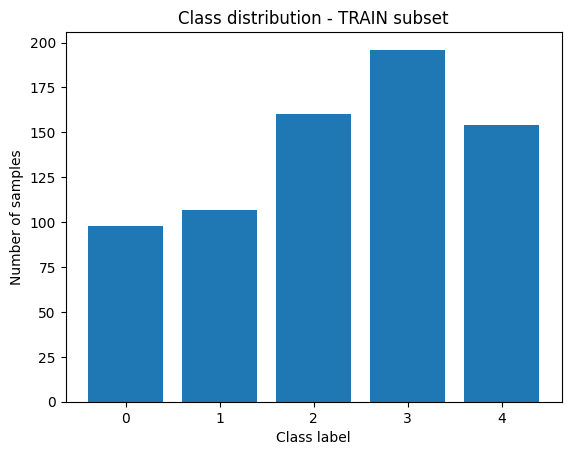

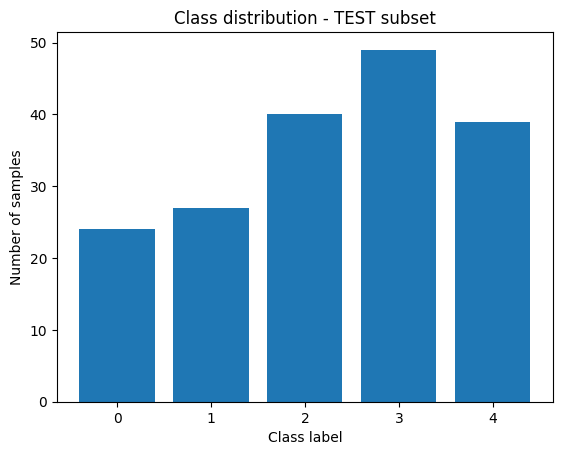

In [ ]:
classes_tr, counts_tr = np.unique(y_train_use, return_counts=True)
plt.figure()
plt.bar(classes_tr, counts_tr)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution - TRAIN subset")
plt.xticks(classes_tr)
plt.show()

classes_te, counts_te = np.unique(y_test_use, return_counts=True)
plt.figure()
plt.bar(classes_te, counts_te)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution - TEST subset")
plt.xticks(classes_te)
plt.show()

## Check distribution in classes after taking 10000 and 5000. (CIFAR 10)

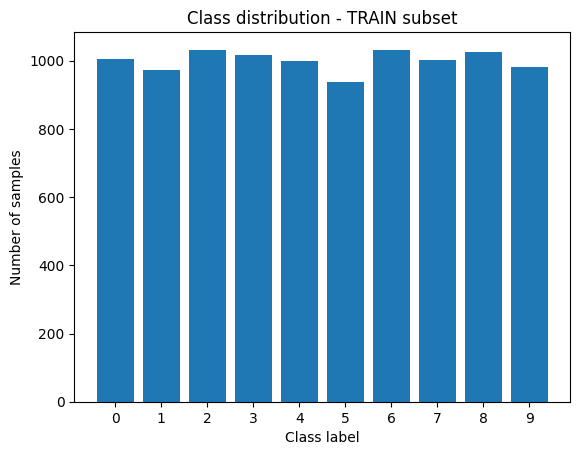

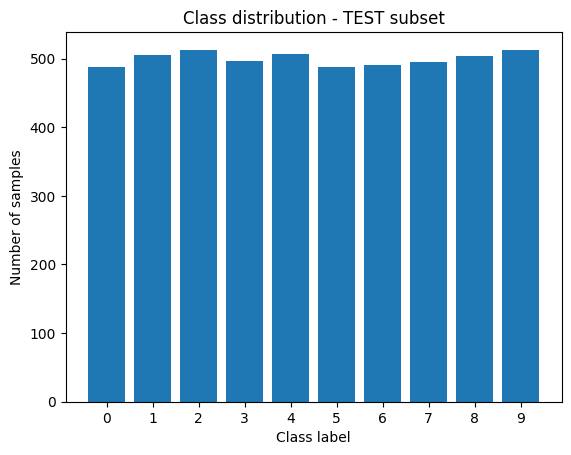

In [ ]:
classes_tr, counts_tr = np.unique(y_train_use, return_counts=True)
plt.figure()
plt.bar(classes_tr, counts_tr)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution - TRAIN subset")
plt.xticks(classes_tr)
plt.show()

classes_te, counts_te = np.unique(y_test_use, return_counts=True)
plt.figure()
plt.bar(classes_te, counts_te)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution - TEST subset")
plt.xticks(classes_te)
plt.show()